# Task 1

In [58]:
import pdfplumber
import re, json, csv
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## First, we create a list pdf_paths that contains the file paths for each book (1st, 2nd, and 3rd volumes).

Then, we initialize an empty list books where we will store the extracted text.
For each file path in pdf_paths, the code:
Opens the PDF using the pdfplumber library.
Iterates through all pages of the PDF.
Extracts the text from each page (p.extract_text()), or saves an empty string if the page is blank.
Collects all the pages of the book into a list and appends this list to books.
Finally, the program prints a confirmation message showing:
How many books were successfully loaded.
The total number of pages across all three books.
This ensures that our dataset is correctly imported and ready for cleaning and analysis.

In [59]:
import pdfplumber
import re, json, csv
import os

# -----------------------------
# File paths for 3 volumes
# -----------------------------
pdf_paths = [
    r"C:\Users\Ислам\Desktop\Hard work\lab work\1.pdf",
    r"C:\Users\Ислам\Desktop\Hard work\lab work\2.pdf",
    r"C:\Users\Ислам\Desktop\Hard work\lab work\3.pdf"
]

# Output folder
output_dir = r"C:\Users\Ислам\Desktop\Hard work\lab work"

# -----------------------------
# Cleaning function
# -----------------------------
def clean_text(text):
    text = re.sub(r"-\n\s*", "", text)   # remove hyphenation
    text = re.sub(r"\s+", " ", text)     # normalize spaces
    return text.strip()

# -----------------------------
# Load and clean each book
# -----------------------------
books = []
for path in pdf_paths:
    with pdfplumber.open(path) as pdf:
        pages = [p.extract_text() or "" for p in pdf.pages]
        cleaned_pages = [clean_text(p) for p in pages]
        books.append(cleaned_pages)

print(f"✅ Loaded {len(books)} books, with {sum(len(b) for b in books)} pages total")

# -----------------------------
# Combine into one dataset
# -----------------------------
dataset = []
for book_id, book in enumerate(books, 1):
    for page_num, text in enumerate(book, 1):
        dataset.append({
            "book": book_id,
            "page": page_num,
            "text": text
        })

print(f"✅ Dataset created with {len(dataset)} pages total")

# -----------------------------
# Save dataset in multiple formats
# -----------------------------
# TXT
txt_path = os.path.join(output_dir, "koshpendiler_dataset.txt")
with open(txt_path, "w", encoding="utf-8") as f:
    for row in dataset:
        f.write(row["text"] + "\n")

# CSV
csv_path = os.path.join(output_dir, "koshpendiler_dataset.csv")
with open(csv_path, "w", encoding="utf-8", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["book", "page", "text"])
    writer.writeheader()
    writer.writerows(dataset)

# JSON
json_path = os.path.join(output_dir, "koshpendiler_dataset.json")
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(dataset, f, ensure_ascii=False, indent=2)

print(f"✅ Dataset saved to:\n- {txt_path}\n- {csv_path}\n- {json_path}")




✅ Loaded 3 books, with 1110 pages total
✅ Dataset created with 1110 pages total
✅ Dataset saved to:
- C:\Users\Ислам\Desktop\Hard work\lab work\koshpendiler_dataset.txt
- C:\Users\Ислам\Desktop\Hard work\lab work\koshpendiler_dataset.csv
- C:\Users\Ислам\Desktop\Hard work\lab work\koshpendiler_dataset.json


## 📖 Code Explanation

This code cleans and combines books. Each book is stored as a list of pages. For every book, it:

Cleans each page with clean_text.

Joins the cleaned pages into one long string.

Saves the result into clean_books.

At the end, it reports how many books were processed and the length of each cleaned book.

In short: turns raw page data into clean, continuous book texts ready for analysis.

In [60]:
def clean_text(txt):
    txt = re.sub(r"-\n\s*", "", txt)   
    txt = re.sub(r"\s+", " ", txt)    
    return txt.strip()




In [61]:
clean_books = []
for b in books:
    clean_pages = [clean_text(p) for p in b]
    clean_books.append(" ".join(clean_pages))

len(clean_books), [len(cb) for cb in clean_books]  


(3, [644745, 601015, 694742])

## 📖 Code Explanation

This code prepares words and sentences from the cleaned books:

word_pattern = re.compile(r"[^\W\d_]+", flags=re.UNICODE)
→ Defines a regex that matches words made only of letters (ignores digits, underscores, punctuation).

books_words
→ For each book, finds all words using the regex, converts them to lowercase, and stores them as lists of words.

books_sentences
→ For each book, splits the text into sentences using ., !, ?, or … as delimiters.
→ Removes empty pieces and strips extra spaces.

Result:

books_words = list of words per book (cleaned + lowercase).

books_sentences = list of sentences per book (properly split).

In short: this step structures the text into words and sentences, making it ready for deeper analysis (like frequency counts or NLP).

In [62]:
word_pattern = re.compile(r"[^\W\d_]+", flags=re.UNICODE)

books_words = [[w.lower() for w in word_pattern.findall(cb)] for cb in clean_books]
books_sentences = [
    [s.strip() for s in re.split(r'(?<=[\.\!\?\…])\s+', cb) if s.strip()]
    for cb in clean_books
]



## 📖 Code Explanation

This part of the code loops through each processed book and prints summary statistics:

It uses enumerate(zip(...), 1) to iterate over each book’s words and sentences together, starting the book index at 1.

For every book, it prints:

Total words → number of words in the book.

Total sentences → number of sentences in the book.

Unique words → count of distinct words (vocabulary size).

Average sentence length → ratio of total words to total sentences, rounded to 2 decimals.

In short: This step provides a quick statistical overview of each book’s structure, showing how long the text is, how varied the vocabulary is, and how long sentences tend to be.

In [63]:
for i, (words, sentences) in enumerate(zip(books_words, books_sentences), 1):
    print(f"\n📘 Book {i}")
    print("Total words:", len(words))
    print("Total sentences:", len(sentences))
    print("Unique words:", len(set(words)))
    print("Average sentence length:", round(len(words)/len(sentences), 2))





📘 Book 1
Total words: 91373
Total sentences: 8072
Unique words: 18435
Average sentence length: 11.32

📘 Book 2
Total words: 85644
Total sentences: 7893
Unique words: 17691
Average sentence length: 10.85

📘 Book 3
Total words: 98768
Total sentences: 8594
Unique words: 19785
Average sentence length: 11.49


## 📖 Code Explanation

This part of the code focuses on word frequency analysis after removing common stopwords:

stopwords = {...}
→ A set of Kazakh words (and a few others) that are too common or uninformative for analysis (like “мен”, “және”, “бұл”). These are excluded to highlight more meaningful words.

filtered_words = [w for w in words if w not in stopwords]
→ Creates a list of all words from the book, but only keeps those that are not in the stopword set.

word_counts = Counter(filtered_words)
→ Counts how many times each remaining word appears.

top20 = word_counts.most_common(20)
→ Extracts the 20 most frequent words.

top_df = pd.DataFrame(top20, columns=["word","count"])
→ Converts the top 20 word counts into a DataFrame with two columns: word and count.
→ Easier to view, analyze, and later plot.

In short: This code identifies the most frequently used meaningful words in the book by filtering out filler words and then ranking the rest.

In [64]:
stopwords = {
    "мен","бен","пен","және","әрі","да","де","та","те",
    "kz","бір","деп","еді","енді","ол","ал","бұл","ғана",
    "есенберлин","сол","не","тек","кенесарының",'i'
}

words = books_words[0]  
filtered_words = [w for w in words if w not in stopwords]

word_counts = Counter(filtered_words)
top20 = word_counts.most_common(20)
top_df = pd.DataFrame(top20, columns=["word","count"])
top_df


,word,count
0,хан,833
1,осы,417
2,жоқ,377
3,алмас,359
4,әбілқайыр,358
5,қылыш,352
6,қор,345
7,әдеби,340
8,iлияс,339
9,көшпендiлер,339


C:\Users\Ислам\AppData\Local\Temp\ipykernel_21888\1449494285.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




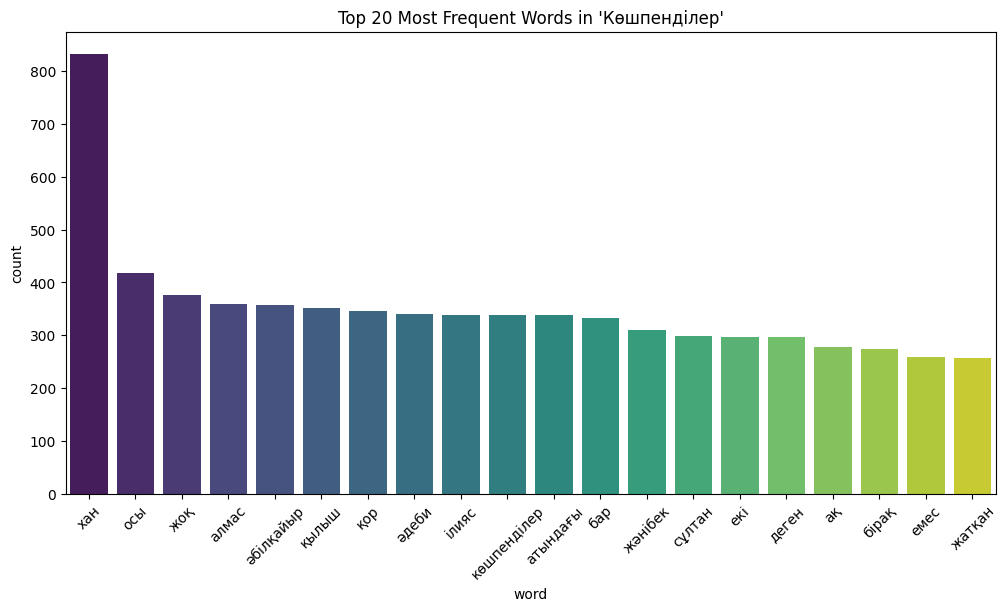

In [65]:
plt.figure(figsize=(12,6))
sns.barplot(x="word", y="count", data=top_df, palette="viridis")
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words in 'Көшпенділер'")
plt.show()





## 📖 Code Explanation

This code analyzes sentence lengths and visualizes their distribution:

sent_lengths = [len(word_pattern.findall(s)) for s in sentences]
→ For each sentence in the book, it counts how many words appear (using the same regex word_pattern).
→ Produces a list of sentence lengths measured in words.

plt.figure(figsize=(10,5))
→ Sets the size of the plot (10 by 5 inches).

sns.histplot(..., bins=40, kde=True, color="teal")
→ Creates a histogram of sentence lengths:

bins=40 → divides sentence lengths into 40 intervals.

kde=True → overlays a smooth density curve to show the distribution shape.

color="teal" → sets bar/curve color.

Axis labels and title clearly describe what the chart shows.

plt.show() → displays the plot.

Result: The chart reveals how sentence lengths are distributed in the book “Көшпенділер” — for example, whether most sentences are short, long, or varied.

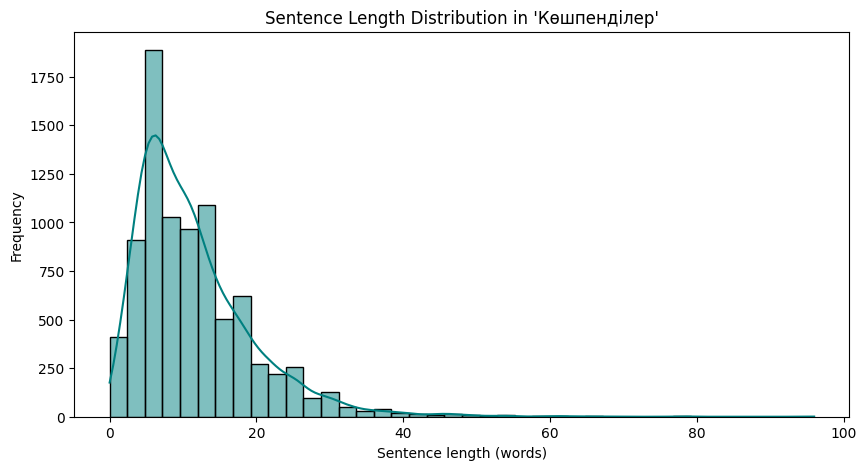

In [66]:
sent_lengths = [len(word_pattern.findall(s)) for s in sentences]

plt.figure(figsize=(10,5))
sns.histplot(sent_lengths, bins=40, kde=True, color="teal")
plt.xlabel("Sentence length (words)")
plt.ylabel("Frequency")
plt.title("Sentence Length Distribution in 'Көшпенділер'")
plt.show()


C:\Users\Ислам\AppData\Local\Temp\ipykernel_21888\1658718628.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




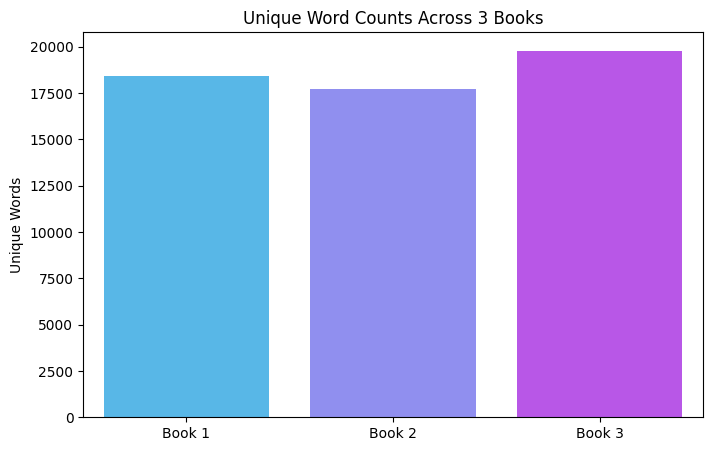

In [67]:
unique_counts = [len(set(words)) for words in books_words]
plt.figure(figsize=(8,5))
sns.barplot(x=[f"Book {i}" for i in range(1,4)], y=unique_counts, palette="cool")
plt.ylabel("Unique Words")
plt.title("Unique Word Counts Across 3 Books")
plt.show()


C:\Users\Ислам\AppData\Local\Temp\ipykernel_21888\300093936.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




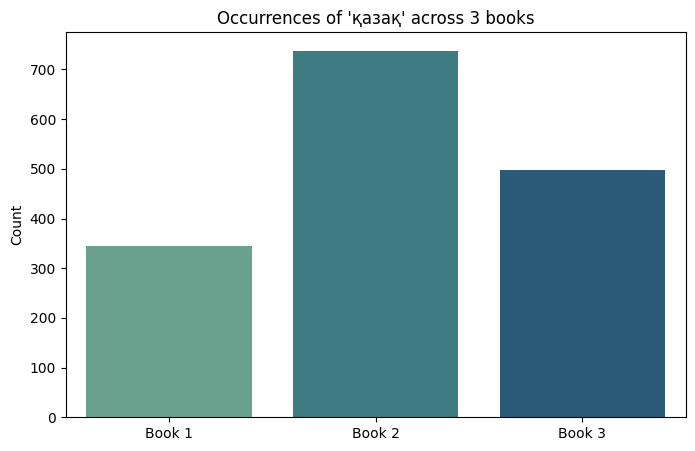

[344, 738, 497]

In [68]:
keyword = "қазақ"
counts = [sum(1 for w in words if keyword in w) for words in books_words]

plt.figure(figsize=(8,5))
sns.barplot(x=[f"Book {i}" for i in range(1,4)], y=counts, palette="crest")
plt.title(f"Occurrences of '{keyword}' across 3 books")
plt.ylabel("Count")
plt.show()

counts


In [71]:
from wordcloud import WordCloud


C:\Users\Ислам\AppData\Local\Temp\ipykernel_21888\2535617572.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




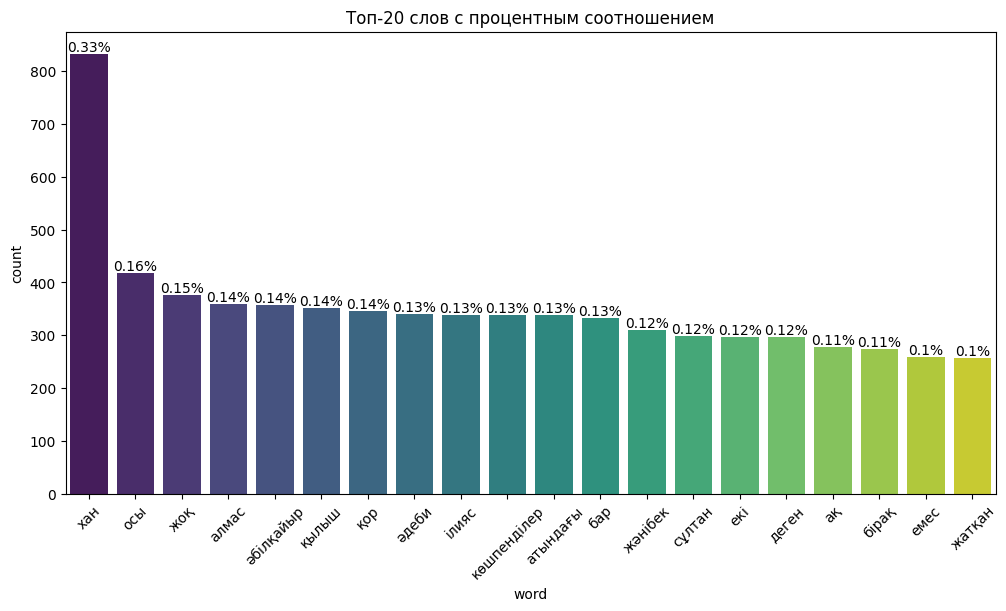

In [ ]:
stopwords = {"мен","бен","пен","және","әрі","да","де","та","те","kz","бір","деп","еді",
             "енді","ол","ал","бұл","ғана","есенберлин","сол","не","тек","кенесарының","i"}

words = books_words[0]  
filtered_words = [w for w in words if w not in stopwords]
word_counts = Counter(filtered_words)

all_words = [w for words in books_words for w in words if w not in stopwords]
total_words = len(all_words)

top20 = word_counts.most_common(20)
top_df = pd.DataFrame(top20, columns=["word","count"])
top_df["percent"] = round((top_df["count"] / total_words) * 100, 2)

plt.figure(figsize=(12,6))
sns.barplot(x="word", y="count", data=top_df, palette="viridis")
for i, row in top_df.iterrows():
    plt.text(i, row["count"]+5, f"{row['percent']}%", ha="center")
plt.xticks(rotation=45)
plt.title("Топ-20 слов с процентным соотношением")
plt.show()


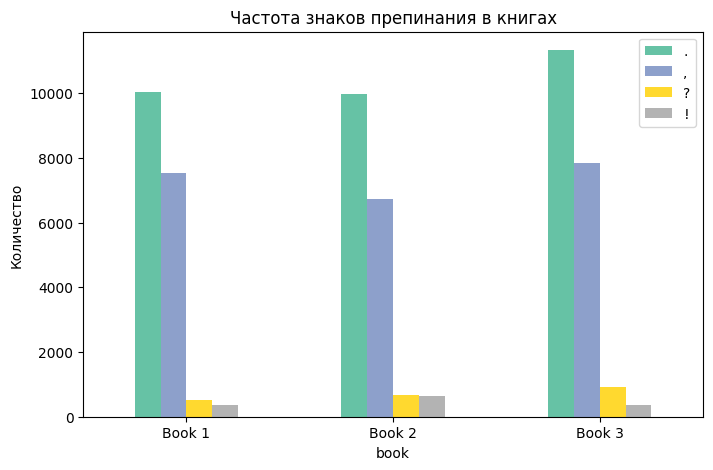

In [73]:
punctuation = [".", ",", "?", "!"]
punct_counts = []

for i, book in enumerate(clean_books, 1):
    counts = {p: book.count(p) for p in punctuation}
    counts["book"] = f"Book {i}"
    punct_counts.append(counts)

punct_df = pd.DataFrame(punct_counts).set_index("book")

punct_df.plot(kind="bar", figsize=(8,5), colormap="Set2")
plt.title("Частота знаков препинания в книгах")
plt.ylabel("Количество")
plt.xticks(rotation=0)
plt.show()


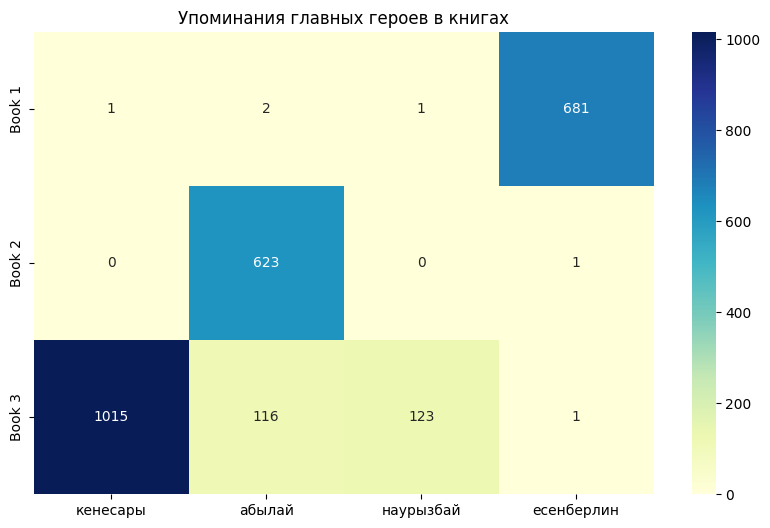

In [74]:
heroes = ["кенесары", "абылай", "наурызбай", "есенберлин"]
hero_counts = []

for words in books_words:
    hero_counts.append([sum(1 for w in words if hero in w) for hero in heroes])

hero_df = pd.DataFrame(hero_counts, columns=heroes, index=[f"Book {i}" for i in range(1,4)])

plt.figure(figsize=(10,6))
sns.heatmap(hero_df, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Упоминания главных героев в книгах")
plt.show()


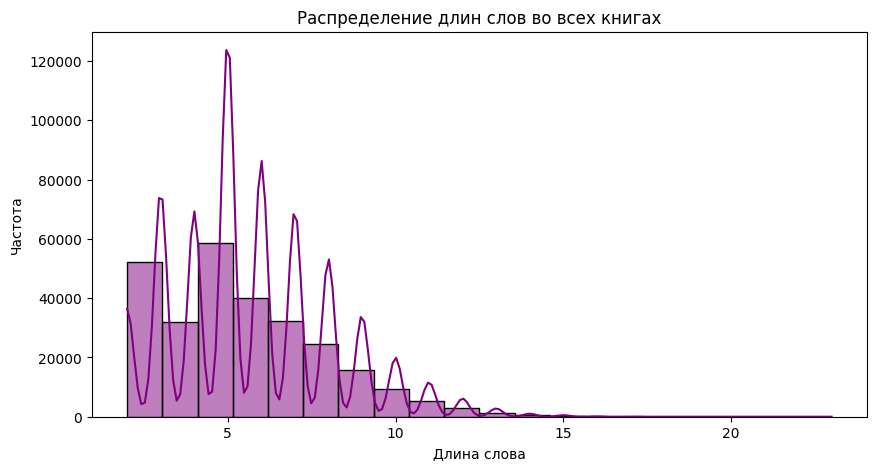

In [75]:
word_lengths = [len(w) for words in books_words for w in words if len(w) > 1]

plt.figure(figsize=(10,5))
sns.histplot(word_lengths, bins=20, kde=True, color="purple")
plt.xlabel("Длина слова")
plt.ylabel("Частота")
plt.title("Распределение длин слов во всех книгах")
plt.show()


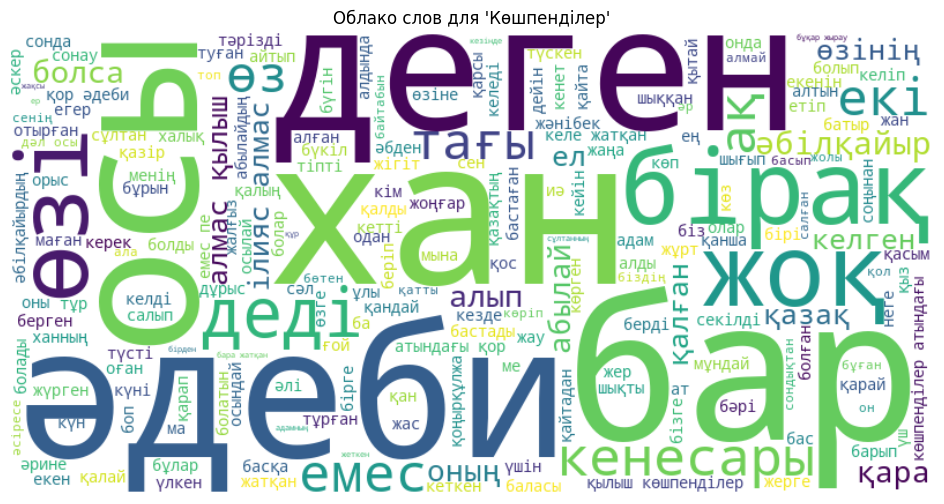

In [77]:
text_all = " ".join(all_words)
wc = WordCloud(width=800, height=400, background_color="white", colormap="viridis").generate(text_all)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Облако слов для 'Көшпенділер'")
plt.show()


## Task 2

In [17]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from bs4 import BeautifulSoup
import pandas as pd
import time
import random




## 📖 Code Explanation

This code sets up a headless Chrome browser for web scraping with Selenium:

options = webdriver.ChromeOptions()
→ Creates a Chrome options object to configure the browser.

options.add_argument("--headless")
→ Runs Chrome in headless mode (no visible browser window). Useful for servers or background scraping.

options.add_argument("--disable-gpu")
→ Disables GPU rendering (improves stability in headless environments).

options.add_argument("--no-sandbox")
→ Prevents sandboxing issues, especially when running on Linux servers.

options.add_argument("--disable-dev-shm-usage")
→ Avoids problems with limited shared memory in Docker/VM environments.

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
→ Launches a Chrome browser instance:

ChromeDriverManager().install() automatically downloads and manages the correct ChromeDriver version.

options=options applies the headless and other configurations.

Result: You now have a Selenium WebDriver running Chrome in the background without opening a visible window, ready to scrape web pages efficiently.

In [16]:
options = webdriver.ChromeOptions()
options.add_argument("--headless")  # без окна
options.add_argument("--disable-gpu")
options.add_argument("--no-sandbox")
options.add_argument("--disable-dev-shm-usage")

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)




## 📖 Code Explanation

This function introduces random delays between scraping requests to behave more like a real human user and avoid getting blocked:

def random_sleep(a=1, b=3):
→ Defines a function that takes two parameters, a and b, which set the lower and upper bounds for sleep time (default: 1–3 seconds).

time.sleep(random.uniform(a, b))
→ Pauses program execution for a random amount of time between a and b seconds.
→ random.uniform(a, b) generates a floating-point number in that range.

Result:
When called, random_sleep() will wait e.g. 1.8s, 2.5s, or any random duration within the range. This helps to:

Reduce the chance of triggering anti-bot protection.

Mimic human browsing behavior.

In [15]:
def random_sleep(a=1, b=3):
    time.sleep(random.uniform(a, b))





## 📖 Code Explanation

This function scrapes apartment listings from the website krisha.kz until it collects at least target_rows rows (default = 10,000).

🔹 Workflow:

Setup

Starts from page 1 of the Krisha.kz apartment sales section.

Keeps looping until enough data is collected.

Page loading & scrolling

driver.get(base_url + str(page)) → Opens the page in Selenium.

Waits 2 seconds to let content load.

Scrolls down 5 times with execute_script("window.scrollBy(0, 1000);") to trigger lazy loading of more ads.

HTML parsing

BeautifulSoup extracts listings from div.a-card.

If no listings are found, prints a warning and skips to the next page.

Data extraction
For each listing:

Title & Link → From a.a-card__title.

Price → From div.a-card__price.

Location → From div.a-card__subtitle.

Appends structured data into a list of dictionaries.

Progress reporting

After each page, prints how many rows were collected.

Sleeps randomly between 1–3 seconds (random_sleep) to avoid detection.

Data cleaning

Converts the list into a DataFrame.

Removes duplicates by link.

Cleans the price field: strips all non-digits, converts to numeric (price_clean).

Fills missing values with defaults (e.g., "Unknown").

Return

Prints the total number of rows after cleaning.

Returns the clean DataFrame.

✅ In short:

scrape_krisha() automates browsing through Krisha.kz, scrolls to load all ads, extracts key fields (title, price, location, link), cleans the data, and ensures you end up with a large, clean dataset of apartment listings ready for analysis.

In [14]:
def scrape_krisha(target_rows=10000):
    data = []
    page = 1
    base_url = "https://krisha.kz/prodazha/kvartiry/?page="

    while len(data) < target_rows:
        driver.get(base_url + str(page))
        time.sleep(2)  

        for _ in range(5):
            driver.execute_script("window.scrollBy(0, 1000);")
            time.sleep(0.5)

        soup = BeautifulSoup(driver.page_source, "html.parser")
        listings = soup.find_all("div", class_="a-card")

        if not listings:
            print(f"❌ Нет объявлений на странице {page}, пропускаем")
            page += 1
            continue

        for house in listings:
            try:
                title_tag = house.find("a", class_="a-card__title")
                title = title_tag.text.strip() if title_tag else "Unknown"
                link = "https://krisha.kz" + title_tag["href"] if title_tag else None

                price_tag = house.find("div", class_="a-card__price")
                price = price_tag.text.strip() if price_tag else "0"

                location_tag = house.find("div", class_="a-card__subtitle")
                location = location_tag.text.strip() if location_tag else "Unknown"

                data.append({
                    "platform": "krisha",
                    "title": title,
                    "link": link,
                    "price": price,
                    "location": location
                })
            except:
                continue

        print(f"✅ Page {page} done, total rows: {len(data)}")
        page += 1
        random_sleep(1, 3)

    df = pd.DataFrame(data)

    df.drop_duplicates(subset=["link"], inplace=True)

    df["price_clean"] = df["price"].str.replace(r"\D", "", regex=True)
    df["price_clean"] = pd.to_numeric(df["price_clean"], errors="coerce")

    df.fillna({"title": "Unknown", "location": "Unknown", "price": 0}, inplace=True)

    print("✅ Всего строк после очистки:", len(df))
    return df






In [18]:
df_krisha = scrape_krisha(target_rows=10000)




✅ Page 1 done, total rows: 23
✅ Page 2 done, total rows: 43
✅ Page 3 done, total rows: 63
✅ Page 4 done, total rows: 83
✅ Page 5 done, total rows: 103
✅ Page 6 done, total rows: 123
✅ Page 7 done, total rows: 143
✅ Page 8 done, total rows: 163
✅ Page 9 done, total rows: 183
✅ Page 10 done, total rows: 203
✅ Page 11 done, total rows: 223
✅ Page 12 done, total rows: 243
✅ Page 13 done, total rows: 263
✅ Page 14 done, total rows: 283
✅ Page 15 done, total rows: 303
✅ Page 16 done, total rows: 323
✅ Page 17 done, total rows: 343
✅ Page 18 done, total rows: 363
✅ Page 19 done, total rows: 383
✅ Page 20 done, total rows: 403
✅ Page 21 done, total rows: 423
✅ Page 22 done, total rows: 443
✅ Page 23 done, total rows: 463
✅ Page 24 done, total rows: 483
✅ Page 25 done, total rows: 503
✅ Page 26 done, total rows: 523
✅ Page 27 done, total rows: 543
✅ Page 28 done, total rows: 563
✅ Page 29 done, total rows: 583
✅ Page 30 done, total rows: 603
✅ Page 31 done, total rows: 623
✅ Page 32 done, total

In [19]:
df_krisha.head()


,platform,title,link,price,location,price_clean
0,krisha,1-комнатная квартира · 54.62 м²,https://krisha.kz/a/show/1002040611?srchid=019...,от 17 478 400 〒,"160 квартал, 32-ая улица",17478400
1,krisha,3-комнатная квартира · 100.77 м²,https://krisha.kz/a/show/697969342?srchid=0199...,от 74 065 950 〒,"Нура р-н, Е-899 33",74065950
2,krisha,4-комнатная квартира · 80 м² · 5/5 этаж,https://krisha.kz/a/show/1005786291?srchid=019...,14 300 000 〒,мкр Аса,14300000
3,krisha,2-комнатная квартира · 65.43 м²,https://krisha.kz/a/show/1003481202?srchid=019...,от 42 856 650 〒,"Сарайшык р-н, Шамши Калдаяков 14",42856650
4,krisha,2-комнатная квартира · 47.49 м²,https://krisha.kz/a/show/760288056?srchid=0199...,от 27 734 160 〒,"Есильский р-н, Турар Рыскулов 18/1",27734160


In [20]:
df_krisha.drop_duplicates(subset=["link"], inplace=True)

df_krisha["price_clean"] = df_krisha["price"].str.replace(r"\D", "", regex=True)
df_krisha["price_clean"] = pd.to_numeric(df_krisha["price_clean"], errors="coerce")

print("✅ Всего строк после очистки:", len(df_krisha))
df_krisha.head()



✅ Всего строк после очистки: 10003


,platform,title,link,price,location,price_clean
0,krisha,1-комнатная квартира · 54.62 м²,https://krisha.kz/a/show/1002040611?srchid=019...,от 17 478 400 〒,"160 квартал, 32-ая улица",17478400
1,krisha,3-комнатная квартира · 100.77 м²,https://krisha.kz/a/show/697969342?srchid=0199...,от 74 065 950 〒,"Нура р-н, Е-899 33",74065950
2,krisha,4-комнатная квартира · 80 м² · 5/5 этаж,https://krisha.kz/a/show/1005786291?srchid=019...,14 300 000 〒,мкр Аса,14300000
3,krisha,2-комнатная квартира · 65.43 м²,https://krisha.kz/a/show/1003481202?srchid=019...,от 42 856 650 〒,"Сарайшык р-н, Шамши Калдаяков 14",42856650
4,krisha,2-комнатная квартира · 47.49 м²,https://krisha.kz/a/show/760288056?srchid=0199...,от 27 734 160 〒,"Есильский р-н, Турар Рыскулов 18/1",27734160


In [21]:
df_krisha.to_excel("krisha_10000.xlsx", index=False)
print("📂 Данные сохранены в krisha_10000.xlsx")



📂 Данные сохранены в krisha_10000.xlsx


In [22]:
import os

save_path = r"C:\Users\Ислам\Desktop\Hard work\lab work"

csv_file = os.path.join(save_path, "krisha_10000.csv")
df_krisha.to_csv(csv_file, index=False, encoding="utf-8-sig")

excel_file = os.path.join(save_path, "krisha_10000.xlsx")
df_krisha.to_excel(excel_file, index=False)

print(f"📂 Файлы сохранены:\nCSV: {csv_file}\nExcel: {excel_file}")



📂 Файлы сохранены:
CSV: C:\Users\Ислам\Desktop\Hard work\lab work\krisha_10000.csv
Excel: C:\Users\Ислам\Desktop\Hard work\lab work\krisha_10000.xlsx


In [23]:
top10 = df_krisha.sort_values(by="price_clean", ascending=False).head(10)

top10[["title", "location", "price", "price_clean", "link"]]


,title,location,price,price_clean,link
5397,7-комнатная квартира · 276 м² · 6/7 этаж,"Медеуский р-н, Митина 4",575 000 000 〒,575000000,https://krisha.kz/a/show/690828605?srchid=0199...
8541,7-комнатная квартира · 500 м² · 19/20 этаж,"Бостандыкский р-н, Аль-Фараби 21 — Каратаева",550 000 000 〒,550000000,https://krisha.kz/a/show/1002655991?srchid=019...
6888,5-комнатная квартира · 432.2 м² · 6/7 этаж,"Медеуский р-н, Достык 132 — Жолдаспекова",540 000 000 〒,540000000,https://krisha.kz/a/show/698899125?srchid=0199...
7746,6-комнатная квартира · 283 м² · 3/3 этаж,"Медеуский р-н, Оспанова 85/52",540 000 000 〒,540000000,https://krisha.kz/a/show/1004918953?srchid=019...
3690,6-комнатная квартира · 386 м²,Медеуский р-н,от 445 000 000 〒,445000000,https://krisha.kz/a/show/695394993?srchid=0199...
7368,5-комнатная квартира · 185.8 м² · 8/9 этаж,"Бостандыкский р-н, Аль-Фараби",415 000 000 〒,415000000,https://krisha.kz/a/show/1005020616?srchid=019...
7395,5-комнатная квартира · 185.8 м² · 8/9 этаж,"Бостандыкский р-н, Аль-Фараби",415 000 000 〒,415000000,https://krisha.kz/a/show/1005020616?srchid=019...
7403,5-комнатная квартира · 185.8 м² · 8/9 этаж,"Бостандыкский р-н, Аль-Фараби",415 000 000 〒,415000000,https://krisha.kz/a/show/1005020616?srchid=019...
3630,5-комнатная квартира · 296 м²,"Медеуский р-н, Аскар Тау 364",от 400 000 000 〒,400000000,https://krisha.kz/a/show/675850991?srchid=0199...
9559,5-комнатная квартира · 309 м²,"Медеуский р-н, Аскар Тау 364",от 400 000 000 〒,400000000,https://krisha.kz/a/show/675843246?srchid=0199...


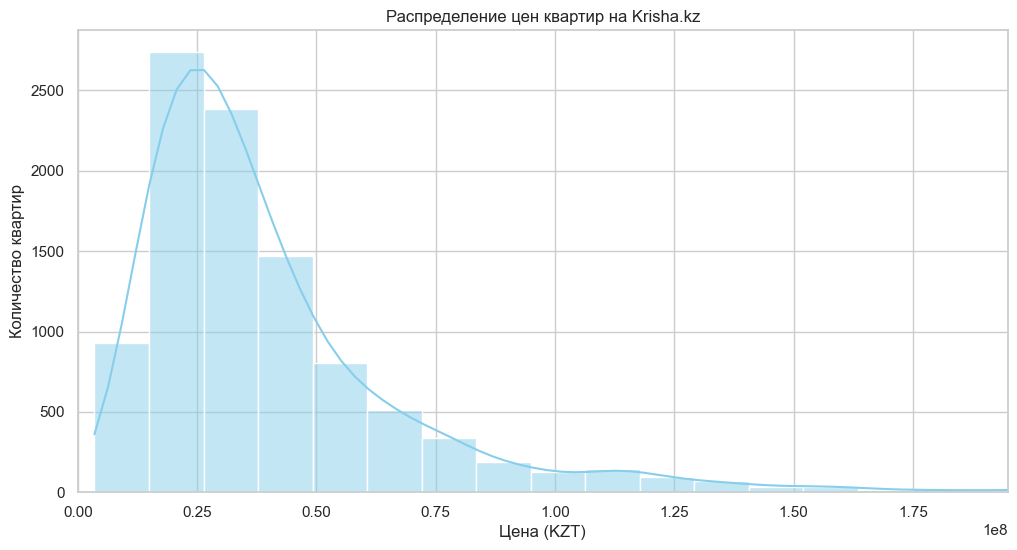

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df_prices = df_krisha[df_krisha["price_clean"] > 0]

plt.figure(figsize=(12,6))
sns.histplot(df_prices["price_clean"], bins=50, kde=True, color="skyblue")
plt.title("Распределение цен квартир на Krisha.kz")
plt.xlabel("Цена (KZT)")
plt.ylabel("Количество квартир")
plt.xlim(0, df_prices["price_clean"].quantile(0.99))  
plt.show()


C:\Users\Ислам\AppData\Local\Temp\ipykernel_19504\2390281587.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_almaty_grouped.values, y=df_almaty_grouped.index, palette="mako")


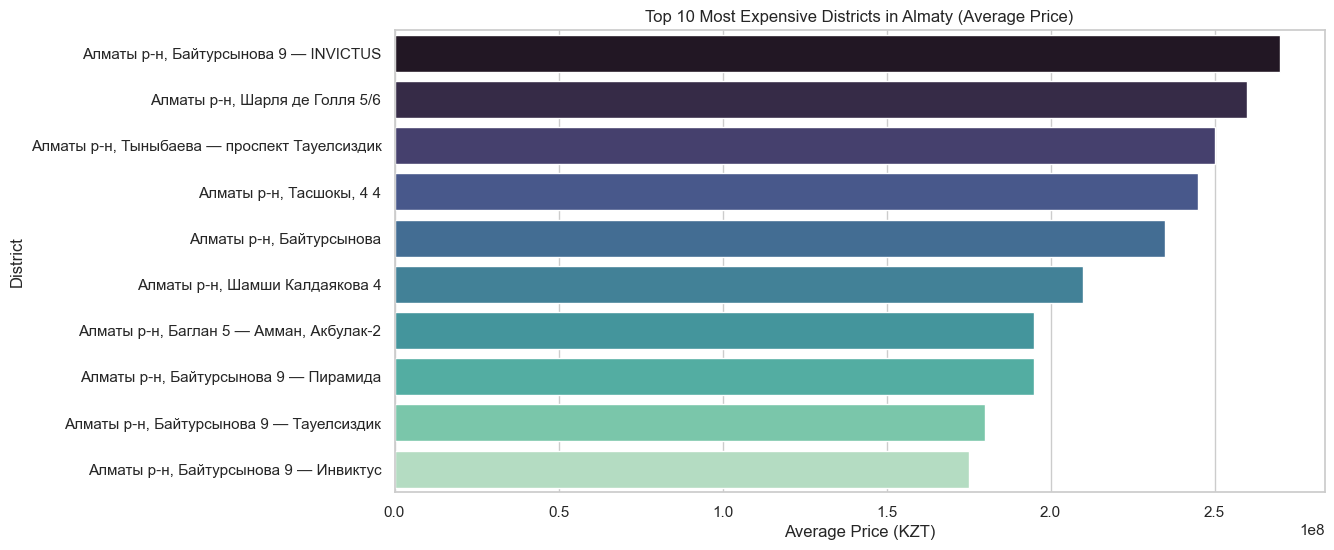

In [25]:
df_almaty = df_krisha[df_krisha["location"].str.contains("Алматы", case=False, na=False)]
df_almaty_grouped = df_almaty.groupby("location")["price_clean"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=df_almaty_grouped.values, y=df_almaty_grouped.index, palette="mako")
plt.title("Top 10 Most Expensive Districts in Almaty (Average Price)")
plt.xlabel("Average Price (KZT)")
plt.ylabel("District")
plt.show()


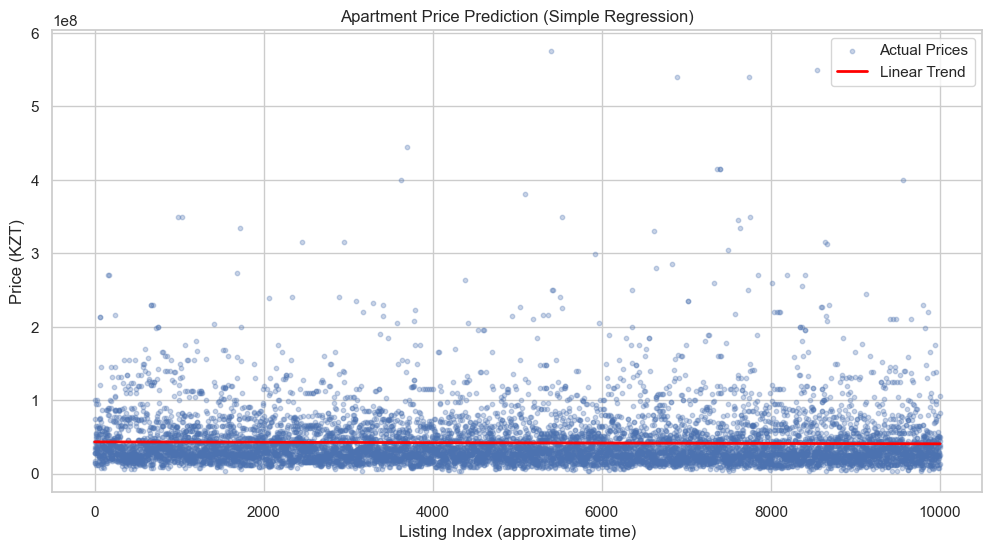

In [32]:
from sklearn.linear_model import LinearRegression
import numpy as np

df_prices = df_krisha[df_krisha["price_clean"] > 0].reset_index(drop=True)
df_prices["index"] = df_prices.index  # artificial time axis

X = df_prices[["index"]]
y = df_prices["price_clean"]

model = LinearRegression()
model.fit(X, y)

df_prices["predicted"] = model.predict(X)

plt.figure(figsize=(12,6))
plt.scatter(df_prices["index"], df_prices["price_clean"], s=10, alpha=0.3, label="Actual Prices")
plt.plot(df_prices["index"], df_prices["predicted"], color="red", linewidth=2, label="Linear Trend")
plt.title("Apartment Price Prediction (Simple Regression)")
plt.xlabel("Listing Index (approximate time)")
plt.ylabel("Price (KZT)")
plt.legend()
plt.show()


In [31]:
import sys
!{sys.executable} -m pip install scikit-learn

   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   -------------------------------


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


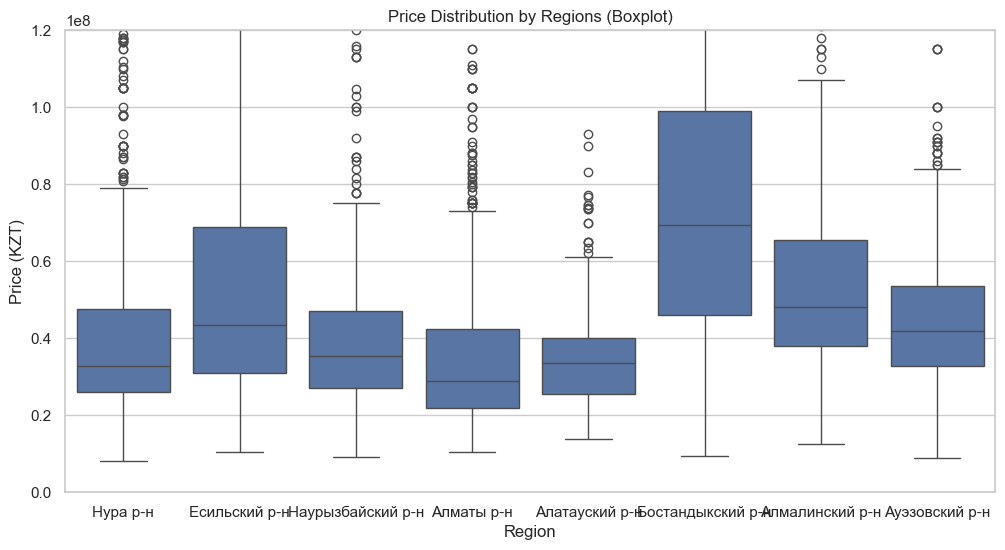

In [28]:
df_regions = df_krisha.copy()
df_regions["region"] = df_regions["location"].str.split(",").str[0]

top_regions = df_regions["region"].value_counts().head(8).index
df_top_regions = df_regions[df_regions["region"].isin(top_regions)]

plt.figure(figsize=(12,6))
sns.boxplot(x="region", y="price_clean", data=df_top_regions)
plt.ylim(0, df_top_regions["price_clean"].quantile(0.95))  # limit outliers
plt.title("Price Distribution by Regions (Boxplot)")
plt.xlabel("Region")
plt.ylabel("Price (KZT)")
plt.show()


C:\Users\Ислам\AppData\Local\Temp\ipykernel_19504\2373798911.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


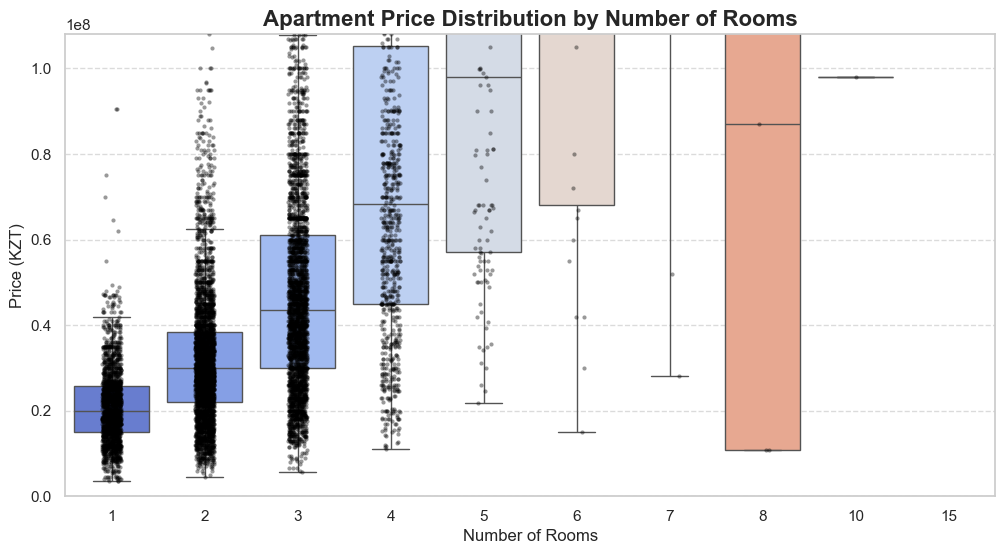

In [34]:
plt.figure(figsize=(12,6))

# Boxplot for price distribution by room count
sns.boxplot(
    x="rooms", 
    y="price_clean", 
    data=df_rooms, 
    palette="coolwarm", 
    showfliers=False  # hide extreme outliers in boxplot
)

# Swarmplot overlay (shows individual data points with jitter)
sns.stripplot(
    x="rooms", 
    y="price_clean", 
    data=df_rooms, 
    color="black", 
    alpha=0.4, 
    size=3, 
    jitter=True
)

# Limit y-axis (remove extreme values)
plt.ylim(0, df_rooms["price_clean"].quantile(0.95))

plt.title("Apartment Price Distribution by Number of Rooms", fontsize=16, fontweight="bold")
plt.xlabel("Number of Rooms", fontsize=12)
plt.ylabel("Price (KZT)", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

